# Oversample Tuning

The fifth experiment focus on understanding the role of the oversample parameter.

As suggested : The regular-sampling step picks $P^2$ samples globally. Why not pick $P$ or $P^3$? What is the role of the *oversampling* factor?

The main focus is on the behavior based on the oversample factor. There are two different experiment, one with more and one with less mpi ranks. Here is reported the common configuration for all the experiments:

* **n_keys** : $5\times10^7$
* **n_ranks** : $8$ or $64$
* **n_threads** : $8$ or $1$
* **keys_distribution** : uniform
* **merging_strategy** : binary

Experiments were executed on [**Orfeo, partition GENOA**](https://orfeo-doc.areasciencepark.it/HPC/computational-resources/).

The key metrics here are **time_communication_seconds** and **total_time_seconds**.

In [13]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

In [14]:
results = pd.read_csv("../parallel/results/oversample_tuning.csv")
results = results[
    ["n_ranks", "oversample", "time_communication_seconds", "time_total_seconds"]
]
results.head()

,n_ranks,oversample,time_communication_seconds,time_total_seconds
0,8,1,0.135428,0.671026
1,8,2,0.099589,0.629340
2,8,4,0.073845,0.613625
3,8,8,0.068565,0.602866
4,8,16,0.063799,0.601275


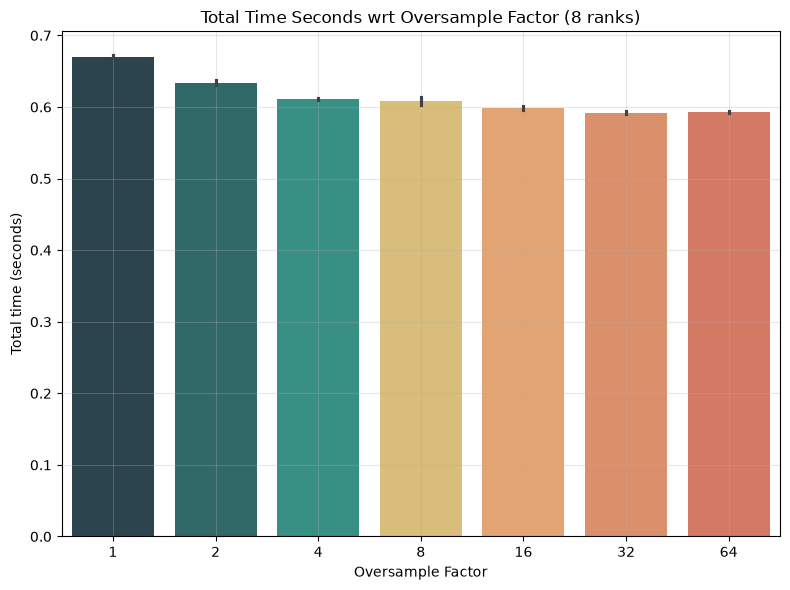

In [15]:
plot_data = results[ results["n_ranks"] == 8]

custom_palette = {
    1: "#264653",
    2: "#287271",
    4: "#2a9d8f",
    8: "#e9c46a",
    16: "#f4a261",
    32: "#ee8959",
    64: "#e76f51",
}


plt.figure(figsize=(8, 6))

sns.barplot(
    data=plot_data,
    x="oversample",
    y="time_total_seconds",
    hue="oversample",
    palette=custom_palette,
    legend=False
)

plt.xlabel("Oversample Factor")
plt.ylabel("Total time (seconds)")
plt.title(f"Total Time Seconds wrt Oversample Factor (8 ranks)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

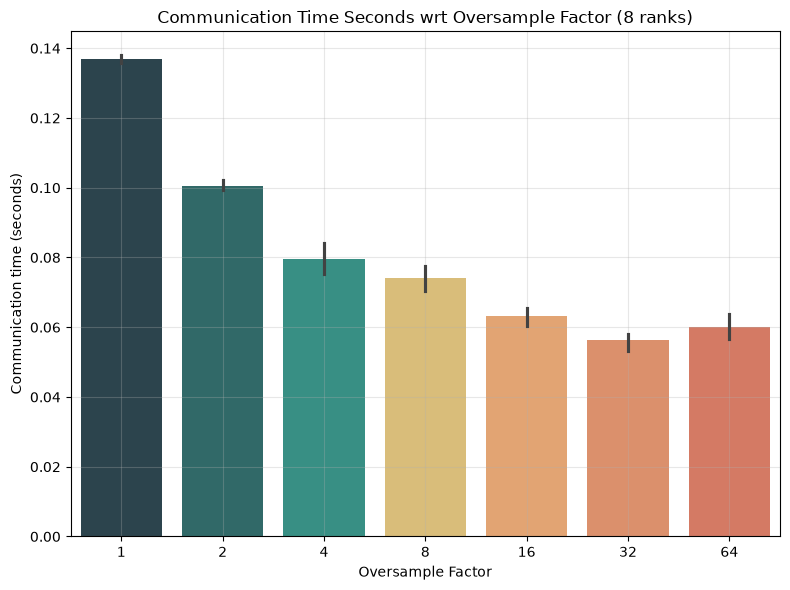

In [16]:
custom_palette = {
    1: "#264653",
    2: "#287271",
    4: "#2a9d8f",
    8: "#e9c46a",
    16: "#f4a261",
    32: "#ee8959",
    64: "#e76f51",
}


plt.figure(figsize=(8, 6))

sns.barplot(
    data=plot_data,
    x="oversample",
    y="time_communication_seconds",
    hue="oversample",
    palette=custom_palette,
    legend=False
)

plt.xlabel("Oversample Factor")
plt.ylabel("Communication time (seconds)")
plt.title(f"Communication Time Seconds wrt Oversample Factor (8 ranks)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()